# Алгоритм K-средних на Python

Давайте создадим свою реализацию алгоритма на питоне, чтобы лучше понимать, как он работает.

Загрузим данные для кластеризации

In [1]:
import pickle
import numpy as np

# данные получены с помощью функции make_classification
with open('data/clustering.pkl', 'rb') as f:
    data_clustering = pickle.load(f)

X = np.array(data_clustering['X'])
Y = np.array(data_clustering['Y'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_22436\2408561099.py:6: DeprecationWarning: numpy.core._multiarray_umath is deprecated and has been renamed to numpy._core._multiarray_umath. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core._multiarray_umath._reconstruct.
  data_clustering = pickle.load(f)


Приступаем к разработке

In [2]:
import numpy as np
from scipy.spatial import distance
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib import pyplot as plt

%matplotlib inline

In [3]:
def random_centroids_selection(X, n, k):
    """Рандомно инициализируем центр кластера"""
    result = []
    for obj_id in np.random.randint(0, n, size=k):
        result.append(X[obj_id, :])
    return result

n, m = X.shape
k = 2

print(n)
centroid_objects = random_centroids_selection(X, n, k)
centroid_objects_prev = [np.zeros(m) for i in range(k)]
print(centroid_objects)
print(centroid_objects_prev)

100
[array([-1.26810263,  0.58652856]), array([0.64033425, 0.02162296])]
[array([0., 0.]), array([0., 0.])]


In [4]:
def eval_weight_evolution(centroid_objects_prev, centroid_objects, k):
    """Вычисляем, как сдвинулись центры за один шаг алгоритма"""
    result = []
    for i in range(k):
        dist = distance.euclidean(
            centroid_objects_prev[i],
            centroid_objects[i]
        )
        result.append(dist)
    return result

print(eval_weight_evolution(centroid_objects_prev, centroid_objects, k))

[1.3971757315345308, 0.6406992341389754]


In [9]:
def eval_cluster_lables(X, centroid_objects):
    """Вычисляем метки кластеров"""
    # формируем матрицу (n x k), которая содержит расстояние от каждого объекта до каждого центроида
    cluster_distance = euclidean_distances(X, centroid_objects)
    #print(cluster_distance)
    # находим минимальное расстояние в каждой строчке - это будет кластер объекта
    cluster_lables = cluster_distance.argmin(axis=1)
    return cluster_lables

print(eval_cluster_lables(X, centroid_objects))

[1 0 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0
 0 0 1 0 1 0 0 0 1 1 1 1 1 0 1 0 0 1 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 0 1
 1 1 0 0 0 1 0 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1]


In [7]:
def eval_centroids(X, k, cluster_lables):
    """Вычисляем новые центроиды с методом усреднения координат"""
    result = []
    for i in range(k):
        new_centroid = X[cluster_lables==i].mean(axis=0)
        result.append(new_centroid)
    return result

шаг 0, смещение кластеров: [0.3362185620782228, 0.7146934446312838]
шаг 1, смещение кластеров: [0.030537800022569336, 0.030261708091210853]
шаг 2, смещение кластеров: [0.0, 0.0]


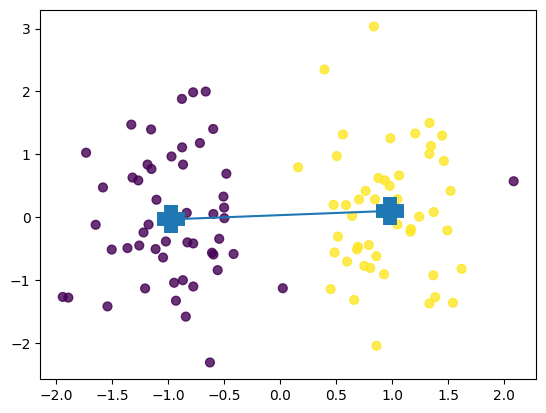

In [10]:
def k_means(X:np.array, k: int=2, eps: float=0.001, num_iteration: int=10) -> np.array:
    """Алгоритм К-средних

    :param X: обучающая выборка
    :param k: количество кластеров
    """
    try:
        n, m = X.shape
    except ValueError:
        print("Обучающая выборка должна быть двумерным массивом (n, m) гдк m - размер выборки")
    # инициализируем центроиды случайным элементом выборки
    centroid_objects = random_centroids_selection(X, n, k)
    centroid_objects_prev = [np.zeros(m) for i in range(k)]
    # расстояние между предыдущим и текущим положением каждого центроида
    weight_evolution = eval_weight_evolution(centroid_objects_prev, centroid_objects, k)
    step = 0
    # условие остановки: центроиды не изменили своего положения
    # повторяем до выполнения условия остановки
    while sum(weight_evolution[i] > eps for i in range(k))!=0 and step < num_iteration:
        # иначе можно прострелить себе ногу =0
        centroid_objects_prev = centroid_objects.copy()
        # вычисляем метки кластеров
        cluster_lables = eval_cluster_lables(X, centroid_objects)
        # усредняем координаты объектов каждого кластера - это новое положение центроида
        centroid_objects = eval_centroids(X, k, cluster_lables)
        # вычисляем расстояние между центроидами на соседних итерациях
        weight_evolution = eval_weight_evolution(centroid_objects_prev, centroid_objects, k)
        print("шаг %s, смещение кластеров: %s" % (step, weight_evolution))
        # обновлённые кластера
        step += 1
    return np.vstack(centroid_objects), cluster_lables


centroids, labels = k_means(X, k=2, num_iteration=10)

plt.scatter(X[:, 0], X[:, 1], s=40, c=Y, marker='o', alpha=0.8, label='data')
plt.plot(centroids[:, 0], centroids[:, 1], marker='+', mew=10, ms=20)
plt.show()

В этом уроке мы реализовали KMeans самоcтоятельно:
* поняли, как алгоритм работает "изнутри"
* прокачали свои навыки программирования

В следующем уроке мы рассмотрим алгоритм DBScan - он тоже решает задачу классификации, но делает это по другому: не надо задавать количество кластеров, вместо понятия "близости" точек мы будем использовать понятие "плотность" (о то, что это такое, мы и узнаем в следующем занятии).